In [88]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [89]:
df = pd.read_csv('train.csv', encoding='utf-8')

df.columns

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='str')

In [90]:
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Month'] = df['Order Date'].dt.month

In [91]:
# Місяці - колонки, міста - рядки
pivot = df.pivot_table(
    values='Sales',
    index='City',
    columns='Month',
    aggfunc='sum'
).fillna(0).round(0).astype(int)

In [92]:
# Місто з найбільшою різницею
seasonal_diff = pivot.max(axis=1) - pivot.min(axis=1)
max_diff_city = seasonal_diff.idxmax()
max_diff_value = seasonal_diff.max()

In [93]:
pivot['Total Sales'] = pivot.sum(axis=1)
top_10_cities = pivot.sort_values(by='Total Sales', ascending=False).head(10)
top_10_cities = top_10_cities.drop(columns='Total Sales')

print("\nТОП-10 міст за продажами:\n")
top_10_cities


ТОП-10 міст за продажами:



Month,1,2,3,4,5,6,7,8,9,10,11,12
City,,,,,,,,,,,,
New York City,2979,2266,10837,7553,13246,17718,11857,14681,55053,33090,47992,35191
Los Angeles,7360,6230,14527,9067,13970,16193,9857,11753,17159,13081,25738,28484
Seattle,3109,3276,24235,2034,3184,9568,8842,16564,11051,3393,14065,16786
San Francisco,5068,244,14268,13903,4349,3399,20974,6836,7412,8295,10360,13933
Philadelphia,4099,1583,5378,5577,14032,5610,6658,13005,21899,3667,16874,10459
Houston,49,2140,8208,6951,4097,2484,2338,988,17680,938,12575,5509
Chicago,203,1341,5127,1116,6205,5361,3976,3782,7036,4786,4343,4544
San Diego,1659,1768,2624,629,993,5109,1113,4590,9001,2135,10032,7867
Jacksonville,1026,0,26526,967,4812,1436,1016,262,1164,3119,2692,1692


In [94]:
print(f"\nМісто з найбільшою сезонною різницею: {max_diff_city}")
print(f"Розмах (Max - Min): {max_diff_value:.2f}")


Місто з найбільшою сезонною різницею: New York City
Розмах (Max - Min): 52787.00


In [95]:
# Витягнення даних міста з найбільшою різницею
city_sales = pivot.loc[max_diff_city].drop('Total Sales', errors='ignore')

mean_sales = city_sales.mean()
std_sales = city_sales.std()

print(f"\nСтатичне пояснення для {max_diff_city}\n")
print(f"Середні продажі на місяць: {mean_sales:.2f}")
print(f"Стандартне відхилення: {std_sales:.2f}")


Статичне пояснення для New York City

Середні продажі на місяць: 21038.58
Стандартне відхилення: 17555.00


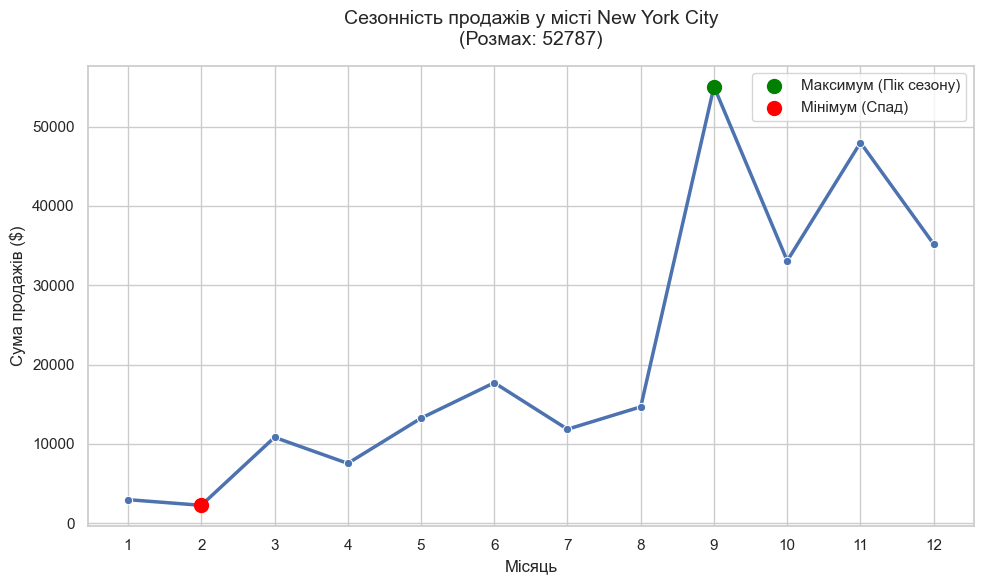

In [96]:
# Графік сезонності
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Лінія продажів
sns.lineplot(x=city_sales.index, y=city_sales.values, marker="o", color="b", linewidth=2.5)

plt.scatter([city_sales.idxmax()], [city_sales.max()], color='green', s=100, zorder=5, label='Максимум (Пік сезону)')
plt.scatter([city_sales.idxmin()], [city_sales.min()], color='red', s=100, zorder=5, label='Мінімум (Спад)')

plt.title(f'Сезонність продажів у місті {max_diff_city}\n(Розмах: {max_diff_value})', fontsize=14, pad=15)
plt.xlabel('Місяць', fontsize=12)
plt.ylabel('Сума продажів ($)', fontsize=12)
plt.xticks(range(1, 13))  # Вісь X = [1; 12]
plt.legend()
plt.tight_layout()

plt.show()